# Smart Energy Recommender

Este notebook desarrolla la primera versión del sistema recomendador energético.  
Se combinan patrones medios de consumo doméstico procedentes del dataset UCI con precios horarios PVPC reales obtenidos mediante la API de e·sios.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga de datos de consumo medio horario (UCI)
hourly_consumption_df = pd.read_csv("../data/hourly_consumption.csv")

# Carga de precios PVPC reales 2023-2024
pvpc_prices = pd.read_csv("../data/pvpc_prices_2023_2024.csv")
pvpc_prices["datetime"] = pd.to_datetime(pvpc_prices["datetime"], utc=True)

# Convertir a hora local española para que las fechas sean correctas
pvpc_prices["datetime"] = pvpc_prices["datetime"].dt.tz_convert("Europe/Madrid")
pvpc_prices["Hour"] = pvpc_prices["datetime"].dt.hour

print("Consumo horario UCI:")
print(hourly_consumption_df.shape)
print("\nPrecios PVPC 2023-2024:")
print(pvpc_prices.shape)

# Verificar que no hay fechas incompletas
horas_por_dia = pvpc_prices.groupby(pvpc_prices["datetime"].dt.date)["Hour"].count()
fechas_incompletas = horas_por_dia[horas_por_dia < 23]
if fechas_incompletas.empty:
    print("\nTodas las fechas tienen datos completos.")
else:
    print(f"\nFechas incompletas detectadas: {fechas_incompletas}")

Consumo horario UCI:
(24, 2)

Precios PVPC 2023-2024:
(17544, 4)

Todas las fechas tienen datos completos.


In [5]:
print("=== Consumo medio por hora (UCI) ===")
display(hourly_consumption_df.head())

print("\n=== Precios PVPC reales ===")
display(pvpc_prices.head())

=== Consumo medio por hora (UCI) ===


,Hour,avg_consumption_kwh
0,0,0.659434
1,1,0.539325
2,2,0.480621
3,3,0.444866
4,4,0.443847



=== Precios PVPC reales ===


,datetime,price_eur_mwh,price_eur_kwh,Hour
0,2022-12-31 23:00:00+00:00,41.45,0.04145,23
1,2023-01-01 00:00:00+00:00,43.01,0.04301,0
2,2023-01-01 01:00:00+00:00,58.07,0.05807,1
3,2023-01-01 02:00:00+00:00,60.69,0.06069,2
4,2023-01-01 03:00:00+00:00,62.91,0.06291,3


=== Estadísticas de precios PVPC 2023-2024 ===
count    17544.0000
mean         0.1373
std          0.0568
min          0.0168
25%          0.0982
50%          0.1375
75%          0.1752
max          0.3572
Name: price_eur_kwh, dtype: float64


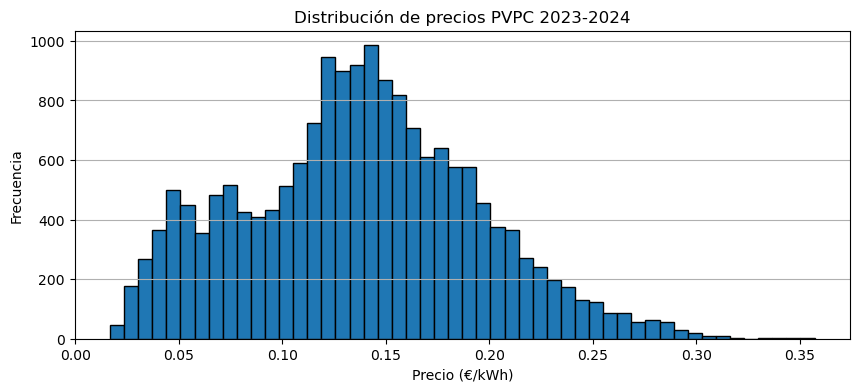

In [6]:
print("=== Estadísticas de precios PVPC 2023-2024 ===")
print(pvpc_prices["price_eur_kwh"].describe().round(4))

# Histograma de distribución de precios
plt.figure(figsize=(10, 4))
plt.hist(pvpc_prices["price_eur_kwh"], bins=50, edgecolor="black")
plt.title("Distribución de precios PVPC 2023-2024")
plt.xlabel("Precio (€/kWh)")
plt.ylabel("Frecuencia")
plt.grid(axis="y")
plt.show()

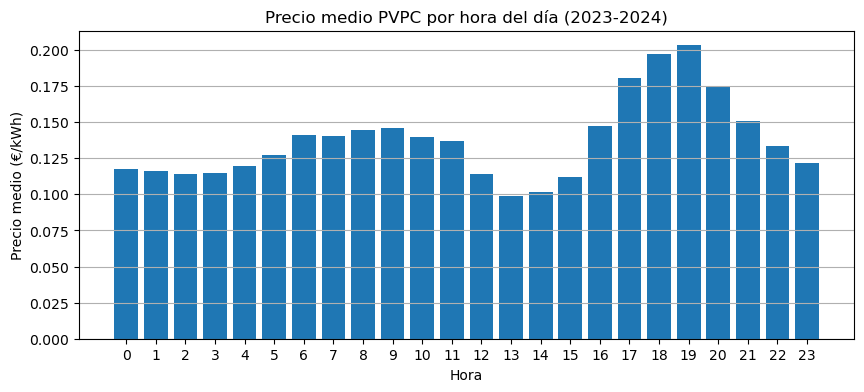


Top 3 horas más baratas en promedio:
Hour
13    0.0992
14    0.1017
15    0.1120
Name: price_eur_kwh, dtype: float64

Top 3 horas más caras en promedio:
Hour
19    0.2032
18    0.1971
17    0.1805
Name: price_eur_kwh, dtype: float64


In [7]:
hourly_avg_price = pvpc_prices.groupby("Hour")["price_eur_kwh"].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg_price.index, hourly_avg_price.values)
plt.title("Precio medio PVPC por hora del día (2023-2024)")
plt.xlabel("Hora")
plt.ylabel("Precio medio (€/kWh)")
plt.xticks(range(0, 24))
plt.grid(axis="y")
plt.show()

print("\nTop 3 horas más baratas en promedio:")
print(hourly_avg_price.nsmallest(3).round(4))
print("\nTop 3 horas más caras en promedio:")
print(hourly_avg_price.nlargest(3).round(4))

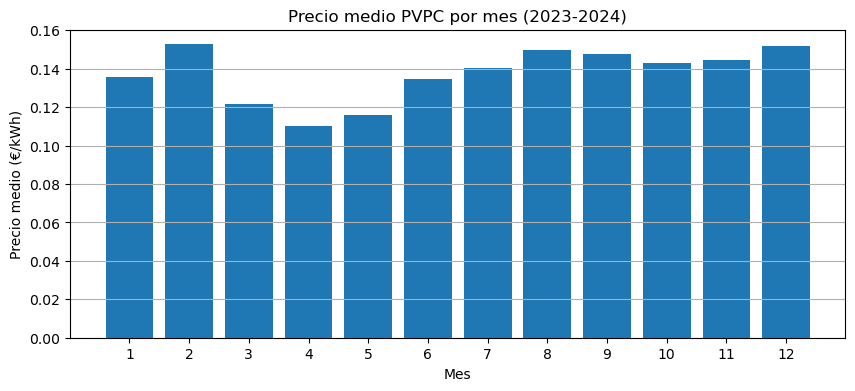


Mes más barato en promedio:
4 0.1102
Mes más caro en promedio:
2 0.1527


In [8]:
pvpc_prices["month"] = pvpc_prices["datetime"].dt.month

monthly_avg_price = pvpc_prices.groupby("month")["price_eur_kwh"].mean()

plt.figure(figsize=(10, 4))
plt.bar(monthly_avg_price.index, monthly_avg_price.values)
plt.title("Precio medio PVPC por mes (2023-2024)")
plt.xlabel("Mes")
plt.ylabel("Precio medio (€/kWh)")
plt.xticks(range(1, 13))
plt.grid(axis="y")
plt.show()

print("\nMes más barato en promedio:")
print(monthly_avg_price.idxmin(), round(monthly_avg_price.min(), 4))
print("Mes más caro en promedio:")
print(monthly_avg_price.idxmax(), round(monthly_avg_price.max(), 4))

In [9]:
def recommend_device_for_day(
    prices_df,
    device_name,
    energy_kwh,
    date,
    allowed_start_hour=0,
    allowed_end_hour=23,
    top_n=5
):
    """
    Recomienda las mejores horas para usar un dispositivo eléctrico
    en un día concreto, basándose en los precios PVPC reales.
    """
    day_prices = prices_df[
        prices_df["datetime"].dt.date == pd.to_datetime(date).date()
    ].copy()

    day_prices = day_prices[
        (day_prices["Hour"] >= allowed_start_hour) &
        (day_prices["Hour"] <= allowed_end_hour)
    ].copy()

    day_prices["device"] = device_name
    day_prices["device_cost_eur"] = day_prices["price_eur_kwh"] * energy_kwh

    recommendations = day_prices.sort_values("device_cost_eur").head(top_n)

    return recommendations[
        ["device", "datetime", "Hour", "price_eur_kwh", "device_cost_eur"]
    ]

In [10]:
recommend_device_for_day(
    prices_df=pvpc_prices,
    device_name="Lavadora",
    energy_kwh=1.0,
    date="2023-01-15",
    allowed_start_hour=7,
    allowed_end_hour=23,
    top_n=5
)

,device,datetime,Hour,price_eur_kwh,device_cost_eur
360,Lavadora,2023-01-15 23:00:00+00:00,23,0.02674,0.02674
351,Lavadora,2023-01-15 14:00:00+00:00,14,0.03695,0.03695
350,Lavadora,2023-01-15 13:00:00+00:00,13,0.04337,0.04337
359,Lavadora,2023-01-15 22:00:00+00:00,22,0.04611,0.04611
349,Lavadora,2023-01-15 12:00:00+00:00,12,0.04667,0.04667


In [11]:
def daily_savings_for_device(
    prices_df,
    device_name,
    energy_kwh,
    date,
    allowed_start_hour=0,
    allowed_end_hour=23
):
    """
    Calcula el ahorro potencial de usar un dispositivo en la mejor hora
    frente a la peor hora del día.
    """
    day_prices = prices_df[
        prices_df["datetime"].dt.date == pd.to_datetime(date).date()
    ].copy()

    day_prices = day_prices[
        (day_prices["Hour"] >= allowed_start_hour) &
        (day_prices["Hour"] <= allowed_end_hour)
    ].copy()

    day_prices["device_cost_eur"] = day_prices["price_eur_kwh"] * energy_kwh

    best = day_prices.loc[day_prices["device_cost_eur"].idxmin()]
    worst = day_prices.loc[day_prices["device_cost_eur"].idxmax()]

    savings_eur = worst["device_cost_eur"] - best["device_cost_eur"]
    savings_pct = (savings_eur / worst["device_cost_eur"]) * 100

    return {
        "device": device_name,
        "date": date,
        "best_hour": int(best["Hour"]),
        "best_price_eur_kwh": round(best["price_eur_kwh"], 4),
        "best_cost_eur": round(best["device_cost_eur"], 4),
        "worst_hour": int(worst["Hour"]),
        "worst_price_eur_kwh": round(worst["price_eur_kwh"], 4),
        "worst_cost_eur": round(worst["device_cost_eur"], 4),
        "savings_eur": round(savings_eur, 4),
        "savings_pct": round(savings_pct, 2)
    }

In [12]:
daily_savings_for_device(
    prices_df=pvpc_prices,
    device_name="Lavadora",
    energy_kwh=1.0,
    date="2023-01-15",
    allowed_start_hour=7,
    allowed_end_hour=23
)

{'device': 'Lavadora',
 'date': '2023-01-15',
 'best_hour': 23,
 'best_price_eur_kwh': 0.0267,
 'best_cost_eur': 0.0267,
 'worst_hour': 19,
 'worst_price_eur_kwh': 0.08,
 'worst_cost_eur': 0.08,
 'savings_eur': 0.0532,
 'savings_pct': 66.57}

In [13]:
devices_catalog = [
    {
        "device_name": "Lavadora",
        "energy_kwh": 1.0,
        "allowed_start_hour": 7,
        "allowed_end_hour": 23
    },
    {
        "device_name": "Lavavajillas",
        "energy_kwh": 1.3,
        "allowed_start_hour": 8,
        "allowed_end_hour": 23
    },
    {
        "device_name": "Secadora",
        "energy_kwh": 2.0,
        "allowed_start_hour": 9,
        "allowed_end_hour": 22
    },
    {
        "device_name": "Termo eléctrico",
        "energy_kwh": 2.5,
        "allowed_start_hour": 0,
        "allowed_end_hour": 23
    }
]

In [14]:
user_profiles = {
    "trabajador": {
        "start_hour": 18,
        "end_hour": 23
    },
    "flexible": {
        "start_hour": 0,
        "end_hour": 23
    },
    "mañanas": {
        "start_hour": 7,
        "end_hour": 15
    },
    "nocturno": {
        "start_hour": 0,
        "end_hour": 7
    }
}

In [15]:
def recommend_for_profile(
    prices_df,
    device_name,
    energy_kwh,
    date,
    profile_name,
    top_n=3
):
    """
    Recomienda las mejores horas para un dispositivo según el perfil
    horario del usuario.
    """
    profile = user_profiles[profile_name]

    recommendations = recommend_device_for_day(
        prices_df=prices_df,
        device_name=device_name,
        energy_kwh=energy_kwh,
        date=date,
        allowed_start_hour=profile["start_hour"],
        allowed_end_hour=profile["end_hour"],
        top_n=top_n
    )

    recommendations = recommendations.copy()
    recommendations["profile"] = profile_name

    return recommendations

In [16]:
print("=== Perfil trabajador ===")
display(recommend_for_profile(
    prices_df=pvpc_prices,
    device_name="Lavadora",
    energy_kwh=1.0,
    date="2023-01-15",
    profile_name="trabajador"
))

print("\n=== Perfil nocturno ===")
display(recommend_for_profile(
    prices_df=pvpc_prices,
    device_name="Lavadora",
    energy_kwh=1.0,
    date="2023-01-15",
    profile_name="nocturno"
))

=== Perfil trabajador ===


,device,datetime,Hour,price_eur_kwh,device_cost_eur,profile
360,Lavadora,2023-01-15 23:00:00+00:00,23,0.02674,0.02674,trabajador
359,Lavadora,2023-01-15 22:00:00+00:00,22,0.04611,0.04611,trabajador
358,Lavadora,2023-01-15 21:00:00+00:00,21,0.05930,0.05930,trabajador



=== Perfil nocturno ===


,device,datetime,Hour,price_eur_kwh,device_cost_eur,profile
343,Lavadora,2023-01-15 06:00:00+00:00,6,0.04635,0.04635,nocturno
339,Lavadora,2023-01-15 02:00:00+00:00,2,0.04688,0.04688,nocturno
342,Lavadora,2023-01-15 05:00:00+00:00,5,0.04774,0.04774,nocturno


## Primera función del sistema recomendador

In [27]:
def schedule_devices_without_overlap(
    prices_df,
    devices,
    date
):
    """
    Planifica el uso de varios dispositivos en el día asignando a cada uno
    la mejor hora disponible sin que dos dispositivos coincidan en la misma hora.
    Si no hay horas libres para un dispositivo, se asigna la mejor hora
    de su ventana permitida aunque ya esté ocupada.
    """
    scheduled_results = []
    occupied_hours = set()

    for device in devices:
        day_prices = prices_df[
            prices_df["datetime"].dt.date == pd.to_datetime(date).date()
        ].copy()

        day_prices = day_prices[
            (day_prices["Hour"] >= device["allowed_start_hour"]) &
            (day_prices["Hour"] <= device["allowed_end_hour"])
        ].copy()

        # Intentar asignar hora libre
        free_hours = day_prices[
            ~day_prices["Hour"].isin(occupied_hours)
        ].copy()

        # Si no hay horas libres, usar la ventana completa sin restricción de solape
        if free_hours.empty:
            free_hours = day_prices.copy()

        free_hours["device_cost_eur"] = (
            free_hours["price_eur_kwh"] * device["energy_kwh"]
        )

        best = free_hours.sort_values("device_cost_eur").iloc[0]
        occupied_hours.add(int(best["Hour"]))

        scheduled_results.append({
            "device": device["device_name"],
            "recommended_hour": int(best["Hour"]),
            "price_eur_kwh": round(best["price_eur_kwh"], 4),
            "energy_kwh": device["energy_kwh"],
            "estimated_cost_eur": round(best["device_cost_eur"], 4)
        })

    return pd.DataFrame(scheduled_results)

In [36]:
daily_schedule = schedule_devices_without_overlap(
    prices_df=pvpc_prices,
    devices=devices_catalog,
    date="2023-01-15"
)
display(daily_schedule)

optimized_total_cost = daily_schedule["estimated_cost_eur"].sum()
print(f"\nCoste total optimizado: {round(optimized_total_cost, 4)} €")

,device,recommended_hour,price_eur_kwh,energy_kwh,estimated_cost_eur
0,Lavadora,23,0.0267,1.0,0.0267
1,Lavavajillas,14,0.0369,1.3,0.0480
2,Secadora,13,0.0434,2.0,0.0867
3,Termo eléctrico,22,0.0461,2.5,0.1153



Coste total optimizado: 0.2767 €


In [37]:
def baseline_device_costs(
    prices_df,
    devices,
    date,
    baseline_hour=20
):
    """
    Calcula el coste de usar todos los dispositivos a una hora fija
    como escenario de referencia no optimizado.
    """
    day_prices = prices_df[
        prices_df["datetime"].dt.date == pd.to_datetime(date).date()
    ].copy()

    baseline_price = day_prices[
        day_prices["Hour"] == baseline_hour
    ]["price_eur_kwh"].iloc[0]

    results = []
    for device in devices:
        cost = baseline_price * device["energy_kwh"]
        results.append({
            "device": device["device_name"],
            "baseline_hour": baseline_hour,
            "baseline_price_eur_kwh": round(baseline_price, 4),
            "energy_kwh": device["energy_kwh"],
            "baseline_cost_eur": round(cost, 4)
        })

    return pd.DataFrame(results)

In [38]:
baseline_schedule = baseline_device_costs(
    prices_df=pvpc_prices,
    devices=devices_catalog,
    date="2023-01-15",
    baseline_hour=20
)

comparison_df = pd.merge(
    baseline_schedule,
    daily_schedule,
    on=["device", "energy_kwh"]
)

comparison_df["savings_eur"] = (
    comparison_df["baseline_cost_eur"] -
    comparison_df["estimated_cost_eur"]
)

comparison_df["savings_pct"] = (
    comparison_df["savings_eur"] /
    comparison_df["baseline_cost_eur"]
) * 100

display(comparison_df)

,device,baseline_hour,baseline_price_eur_kwh,energy_kwh,baseline_cost_eur,recommended_hour,price_eur_kwh,estimated_cost_eur,savings_eur,savings_pct
0,Lavadora,20,0.068,1.0,0.0680,23,0.0267,0.0267,0.0413,60.735294
1,Lavavajillas,20,0.068,1.3,0.0884,14,0.0369,0.0480,0.0404,45.701357
2,Secadora,20,0.068,2.0,0.1361,13,0.0434,0.0867,0.0494,36.296841
3,Termo eléctrico,20,0.068,2.5,0.1701,22,0.0461,0.1153,0.0548,32.216343


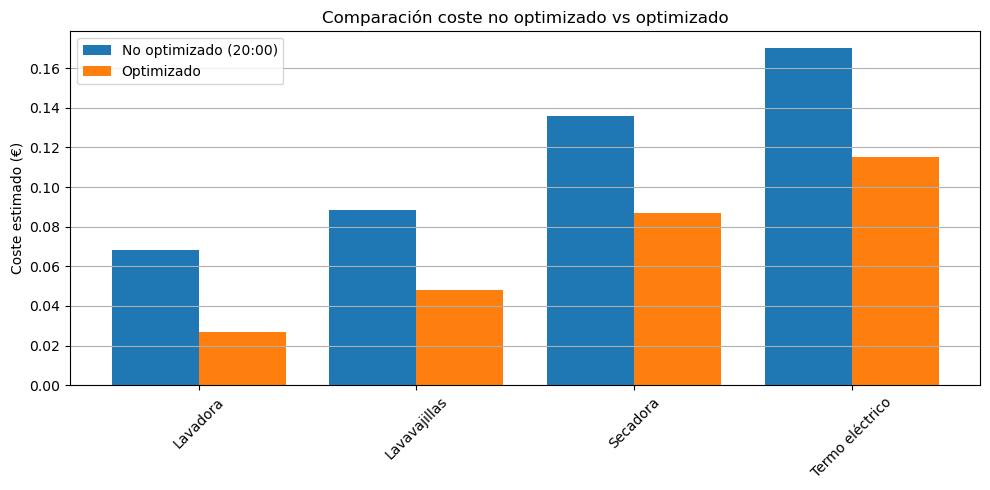

In [39]:
x = range(len(comparison_df))

plt.figure(figsize=(10, 5))
plt.bar(
    [i - 0.2 for i in x],
    comparison_df["baseline_cost_eur"],
    width=0.4,
    label="No optimizado (20:00)"
)
plt.bar(
    [i + 0.2 for i in x],
    comparison_df["estimated_cost_eur"],
    width=0.4,
    label="Optimizado"
)
plt.xticks(x, comparison_df["device"], rotation=45)
plt.ylabel("Coste estimado (€)")
plt.title("Comparación coste no optimizado vs optimizado")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [40]:
total_baseline = comparison_df["baseline_cost_eur"].sum()
total_optimized = comparison_df["estimated_cost_eur"].sum()
total_savings = comparison_df["savings_eur"].sum()
total_savings_pct = (total_savings / total_baseline) * 100

summary = {
    "baseline_total_cost_eur": round(total_baseline, 4),
    "optimized_total_cost_eur": round(total_optimized, 4),
    "total_savings_eur": round(total_savings, 4),
    "total_savings_pct": round(total_savings_pct, 2)
}

print("=== Resumen del día ===")
for k, v in summary.items():
    print(f"{k}: {v}")

=== Resumen del día ===
baseline_total_cost_eur: 0.4626
optimized_total_cost_eur: 0.2767
total_savings_eur: 0.1859
total_savings_pct: 40.19


In [41]:
def generate_recommendation_text(row):
    return (
        f"Para el dispositivo {row['device']}, se recomienda su uso a las "
        f"{row['recommended_hour']}:00. El coste estimado optimizado es de "
        f"{row['estimated_cost_eur']} €, frente a {row['baseline_cost_eur']} € "
        f"en el escenario no optimizado. "
        f"El ahorro estimado es de {round(row['savings_eur'], 4)} €, "
        f"equivalente a un {round(row['savings_pct'], 2)}%."
    )

comparison_df["recommendation_text"] = comparison_df.apply(
    generate_recommendation_text,
    axis=1
)

display(comparison_df[["device", "recommendation_text"]])

,device,recommendation_text
0,Lavadora,"Para el dispositivo Lavadora, se recomienda su..."
1,Lavavajillas,"Para el dispositivo Lavavajillas, se recomiend..."
2,Secadora,"Para el dispositivo Secadora, se recomienda su..."
3,Termo eléctrico,"Para el dispositivo Termo eléctrico, se recomi..."


In [42]:
def evaluate_multiple_days(
    prices_df,
    devices,
    dates,
    baseline_hour=20
):
    """
    Evalúa el ahorro del sistema recomendador sobre múltiples días.
    """
    all_results = []

    for date in dates:
        daily_sched = schedule_devices_without_overlap(
            prices_df=prices_df,
            devices=devices,
            date=date
        )

        baseline_sched = baseline_device_costs(
            prices_df=prices_df,
            devices=devices,
            date=date,
            baseline_hour=baseline_hour
        )

        comparison = pd.merge(
            baseline_sched,
            daily_sched,
            on=["device", "energy_kwh"]
        )

        comparison["date"] = date
        comparison["savings_eur"] = (
            comparison["baseline_cost_eur"] -
            comparison["estimated_cost_eur"]
        )
        comparison["savings_pct"] = (
            comparison["savings_eur"] /
            comparison["baseline_cost_eur"]
        ) * 100

        all_results.append(comparison)

    return pd.concat(all_results, ignore_index=True)

In [46]:
# Usamos los primeros 30 días disponibles para validación
available_dates = (
    pvpc_prices["datetime"]
    .dt.date
    .astype(str)
    .unique()
)

sample_dates = available_dates[:30]

multi_day_results = evaluate_multiple_days(
    prices_df=pvpc_prices,
    devices=devices_catalog,
    dates=sample_dates,
    baseline_hour=20
)

multi_day_results.head()

,device,baseline_hour,baseline_price_eur_kwh,energy_kwh,baseline_cost_eur,recommended_hour,price_eur_kwh,estimated_cost_eur,date,savings_eur,savings_pct
0,Lavadora,20,0.0684,1.0,0.0684,12,0.0542,0.0542,2023-01-01,0.0142,20.760234
1,Lavavajillas,20,0.0684,1.3,0.0889,13,0.0554,0.0720,2023-01-01,0.0169,19.010124
2,Secadora,20,0.0684,2.0,0.1368,14,0.0557,0.1113,2023-01-01,0.0255,18.640351
3,Termo eléctrico,20,0.0684,2.5,0.1710,0,0.0414,0.1036,2023-01-01,0.0674,39.415205
4,Lavadora,20,0.2741,1.0,0.2741,7,0.1616,0.1616,2023-01-02,0.1125,41.043415


In [44]:
for date in sample_dates:
    for device in devices_catalog:
        day_prices = pvpc_prices[
            pvpc_prices["datetime"].dt.date == pd.to_datetime(date).date()
        ].copy()
        
        day_prices = day_prices[
            (day_prices["Hour"] >= device["allowed_start_hour"]) &
            (day_prices["Hour"] <= device["allowed_end_hour"])
        ].copy()
        
        if day_prices.empty:
            print(f"VACÍO — fecha: {date}, dispositivo: {device['device_name']}, "
                  f"horas: {device['allowed_start_hour']}-{device['allowed_end_hour']}")

VACÍO — fecha: 2022-12-31, dispositivo: Secadora, horas: 9-22


In [47]:
daily_summary = (
    multi_day_results
    .groupby("date")
    .agg(
        baseline_total_cost_eur=("baseline_cost_eur", "sum"),
        optimized_total_cost_eur=("estimated_cost_eur", "sum"),
        total_savings_eur=("savings_eur", "sum")
    )
    .reset_index()
)

daily_summary["total_savings_pct"] = (
    daily_summary["total_savings_eur"] /
    daily_summary["baseline_total_cost_eur"]
) * 100

display(daily_summary)

,date,baseline_total_cost_eur,optimized_total_cost_eur,total_savings_eur,total_savings_pct
0,2023-01-01,0.4651,0.3411,0.1240,26.660933
1,2023-01-02,1.8638,1.0746,0.7892,42.343599
2,2023-01-03,1.8816,1.2718,0.6098,32.408588
3,2023-01-04,1.8904,1.0963,0.7941,42.006983
4,2023-01-05,2.0264,0.9929,1.0335,51.001777
5,2023-01-06,1.2655,0.8352,0.4303,34.002371
6,2023-01-07,0.5574,0.2440,0.3134,56.225332
7,2023-01-08,0.4591,0.2313,0.2278,49.618819
8,2023-01-09,1.9184,0.6732,1.2452,64.908257
9,2023-01-10,1.6374,1.0040,0.6334,38.683278


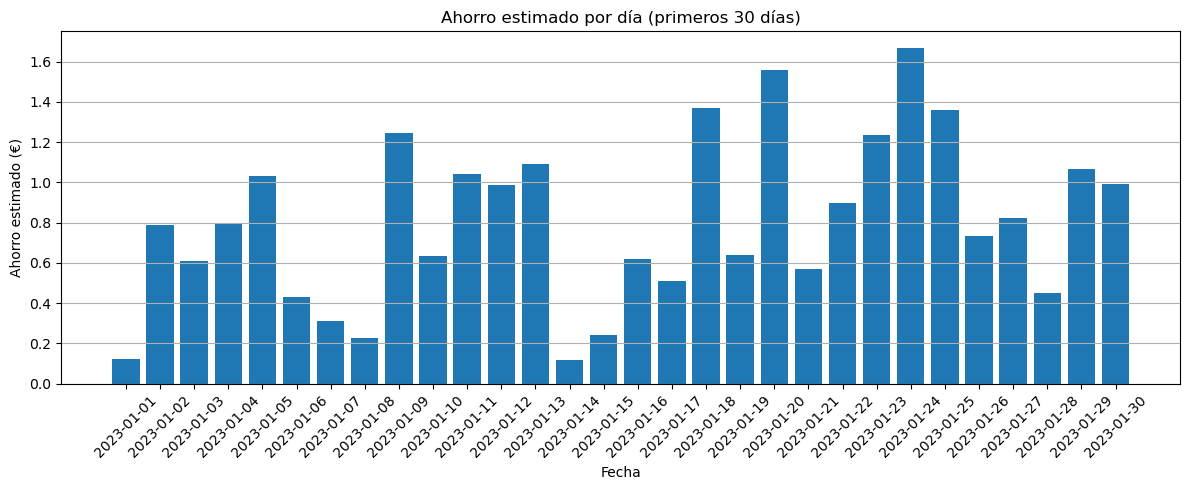

In [48]:
plt.figure(figsize=(12, 5))
plt.bar(daily_summary["date"], daily_summary["total_savings_eur"])
plt.title("Ahorro estimado por día (primeros 30 días)")
plt.xlabel("Fecha")
plt.ylabel("Ahorro estimado (€)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [49]:
overall_summary = {
    "total_days_evaluated": daily_summary["date"].nunique(),
    "avg_baseline_cost_eur": round(daily_summary["baseline_total_cost_eur"].mean(), 4),
    "avg_optimized_cost_eur": round(daily_summary["optimized_total_cost_eur"].mean(), 4),
    "avg_daily_savings_eur": round(daily_summary["total_savings_eur"].mean(), 4),
    "avg_savings_pct": round(daily_summary["total_savings_pct"].mean(), 2),
    "max_daily_savings_eur": round(daily_summary["total_savings_eur"].max(), 4),
    "min_daily_savings_eur": round(daily_summary["total_savings_eur"].min(), 4)
}

print("=== Métricas globales del sistema recomendador ===")
for k, v in overall_summary.items():
    print(f"{k}: {v}")

=== Métricas globales del sistema recomendador ===
total_days_evaluated: 30
avg_baseline_cost_eur: 1.4342
avg_optimized_cost_eur: 0.6284
avg_daily_savings_eur: 0.8058
avg_savings_pct: 54.69
max_daily_savings_eur: 1.6671
min_daily_savings_eur: 0.1189
